Columns in dataset:
Index(['Student_ID', 'Hours_Studied', 'Attendance (%)',
       'Assignments_Submitted', 'Previous_Sem_GPA', 'Participation_Score',
       'Final_Exam_Score', 'Pass_Fail', 'Career_Readiness_Score', 'Age',
       'Gender'],
      dtype='object')

===== REGRESSION RESULTS =====
R2 Score: 0.9781353941989233
MAE: 1.416085749454984

===== CLASSIFICATION RESULTS =====
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Accuracy: 1.0


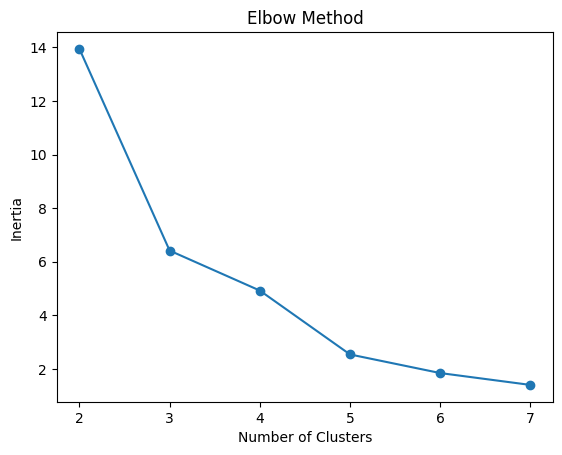


Cluster Distribution:
Cluster
0    9
1    6
2    5
Name: count, dtype: int64

RECOMMENDED INTERVENTIONS
 At Risk Students (Score < 50):
 Extra tutoring
 Academic counseling
 Attendance monitoring

 Average Students:
 Study workshops
 Time management sessions

 High Performers:
 Career mentoring
 Internship programs
Advanced learning opportunities


In [ ]:
#Capstone Project: Student Success & Career Path Prediction

#Scenario

#The university wants to analyze student performance data to:

#Predict exam scores (Regression).
#Classify students into “At Risk” vs. “On Track” categories (Classification).
#Cluster students into groups with similar study habits (Clustering).
#Recommend interventions (extra tutoring, workshops, counseling).

#step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    classification_report,
    accuracy_score
)


#step 2: Load Dataset

df = pd.read_csv("StudentSuccessCareer Path.csv")


df.columns = df.columns.str.strip()

print("Columns in dataset:")
print(df.columns)

#step 3: REGRESSION


X_reg = df[['Hours_Studied', 'Attendance (%)', 'Assignments_Submitted','Previous_Sem_GPA', 'Participation_Score']]
y_reg = df['Final_Exam_Score']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

reg_pred = reg_model.predict(X_test_reg)

print("\n===== REGRESSION RESULTS =====")
print("R2 Score:", r2_score(y_test_reg, reg_pred))
print("MAE:", mean_absolute_error(y_test_reg, reg_pred))

#step 4: CLASSIFICATION
df['Status'] = df['Final_Exam_Score'].apply(lambda x: 0 if x < 50 else 1)

X_clf = df[['Hours_Studied', 'Attendance (%)', 'Assignments_Submitted', 'Previous_Sem_GPA', 'Participation_Score']]
y_clf = df['Status']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_clf = scaler.fit_transform(X_train_clf)
X_test_clf = scaler.transform(X_test_clf)

clf_model = LogisticRegression()
clf_model.fit(X_train_clf, y_train_clf)

clf_pred = clf_model.predict(X_test_clf)

print("\n===== CLASSIFICATION RESULTS =====")
print(classification_report(y_test_clf, clf_pred))
print("Accuracy:", accuracy_score(y_test_clf, clf_pred))

#step 5: CLUSTERING
cluster_features = df[['Hours_Studied', 'Attendance (%)', 'Assignments_Submitted']]

cluster_scaled = scaler.fit_transform(cluster_features)

# Elbow Method
inertia = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Apply KMeans (Assume 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(cluster_scaled)

print("\nCluster Distribution:")
print(df['Cluster'].value_counts())


#step 6: INTERVENTION SUGGESTION

print("\nRECOMMENDED INTERVENTIONS")

print(" At Risk Students (Score < 50):")
print(" Extra tutoring")
print(" Academic counseling")
print(" Attendance monitoring")

print("\n Average Students:")
print(" Study workshops")
print(" Time management sessions")

print("\n High Performers:")
print(" Career mentoring")
print(" Internship programs")
print("Advanced learning opportunities")